<a href="https://colab.research.google.com/github/PittuSaiPrathvik/xyz/blob/main/ML_PROJECT_NEW_FILE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving nellore_traffic_accident_risk_50.csv to nellore_traffic_accident_risk_50.csv


In [3]:
import pandas as pd

data = pd.read_csv("nellore_traffic_accident_risk_50.csv")

Dataset loaded successfully!
Dataset Shape: (50, 12)

First 5 rows:
         Date  Hour         Location  Traffic_Volume   Road_Type  \
0  2023-11-24     9           Kavali             231  Rural Road   
1  2023-10-30     0  Buchireddypalem             245     Highway   
2  2023-04-23     1    Venkatachalam             749     Highway   
3  2023-04-21    20    Nellore Rural             389     Highway   
4  2023-08-24     4           Kavali             435  Urban Road   

  Road_Condition Weather Visibility      Lighting Speed_Level  \
0           Good   Clear       High      Daylight        High   
1           Good   Clear       High  Street Light        High   
2       Moderate   Clear       High          Dark      Medium   
3           Good   Clear       High          Dark        High   
4           Good   Clear       High          Dark        High   

   Previous_Accidents Accident_Risk  
0                   3           Low  
1                   6        Medium  
2                 

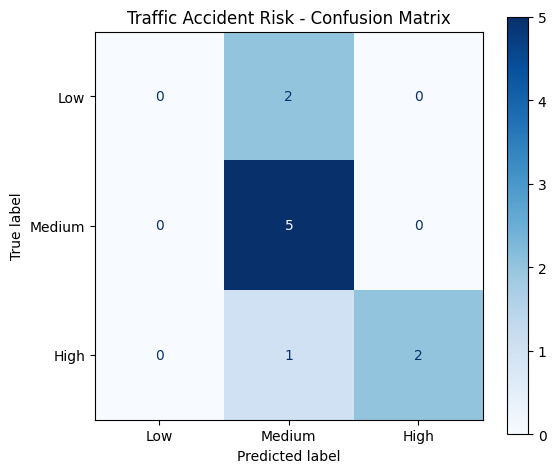


-----------------------------
NEW TRAFFIC CONDITION PREDICTION
-----------------------------
Predicted Accident Risk: High


In [5]:
# ==============================================================
# Traffic Accident Risk Prediction - SPSR Nellore, Andhra Pradesh
# Machine Learning Classification Pipeline
# ==============================================================

import os
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# --------------------------------------------------
# 1. UPLOAD & LOAD DATASET
# --------------------------------------------------
# If file already exists, load directly; otherwise prompt upload
file_name = "nellore_traffic_accident_risk_50.csv"
if not os.path.exists(file_name):
  print("Please upload your dataset CSV file:")
  uploaded = files.upload()
  file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print(f"Dataset Shape: {data.shape}")
print("\nFirst 5 rows:")
print(data.head())

print("\nMissing values:")
print(data.isnull().sum())

print("\nRisk distribution:")
print(data["Accident_Risk"].value_counts())

# --------------------------------------------------
# 2. SELECT FEATURES AND TARGET
# ----------------------------------================
X = data[[
    "Hour",
    "Traffic_Volume",
    "Location",
    "Road_Type",
    "Road_Condition",
    "Weather",
    "Visibility",
    "Lighting",
    "Speed_Level",
    "Previous_Accidents",
]]

y = data["Accident_Risk"]

categorical_features = [
    "Location",
    "Road_Type",
    "Road_Condition",
    "Weather",
    "Visibility",
    "Lighting",
    "Speed_Level",
]

numerical_features = ["Hour", "Traffic_Volume", "Previous_Accidents"]

# Define standard logical order for classes
risk_labels = ["Low", "Medium", "High"]

# --------------------------------------------------
# 3. PREPROCESSING & PIPELINE SETUP
# --------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        ("numerical", "passthrough", numerical_features),
    ]
)

model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)

pipeline = Pipeline(
    steps=[("preprocessing", preprocessor), ("model", model)]
)

# --------------------------------------------------
# 4. SPLIT DATASET (80% Train, 20% Test)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# --------------------------------------------------
# 5. TRAIN MODEL & PREDICT
# --------------------------------------------------
pipeline.fit(X_train, y_train)
print("\nModel training completed!")

y_pred = pipeline.predict(X_test)

# --------------------------------------------------
# 6. MODEL EVALUATION
# --------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\n-----------------------------")
print("MODEL PERFORMANCE")
print("-----------------------------")
print(f"Accuracy: {accuracy * 100:.2f} %")

# Classification report with matching labels and no zero-division warnings
print("\nClassification Report:")
print(
    classification_report(
        y_test, y_pred, labels=risk_labels, zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=risk_labels)
print("\nConfusion Matrix:")
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {lbl}" for lbl in risk_labels],
    columns=[f"Pred {lbl}" for lbl in risk_labels],
)
print(cm_df)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=risk_labels)
disp.plot(cmap="Blues", ax=ax)
plt.title("Traffic Accident Risk - Confusion Matrix")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. PREDICT A NEW TRAFFIC CONDITION
# --------------------------------------------------
new_data = pd.DataFrame({
    "Hour": [20],
    "Traffic_Volume": [900],
    "Location": ["Nellore Urban"],
    "Road_Type": ["Urban Road"],
    "Road_Condition": ["Poor"],
    "Weather": ["Rainy"],
    "Visibility": ["Medium"],
    "Lighting": ["Dark"],
    "Speed_Level": ["High"],
    "Previous_Accidents": [12],
})

prediction = pipeline.predict(new_data)

print("\n-----------------------------")
print("NEW TRAFFIC CONDITION PREDICTION")
print("-----------------------------")
print(f"Predicted Accident Risk: {prediction[0]}")